In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\User\PyCharmMiscProject\Datasets\census-income.csv")
df.columns
df.dtypes


age                 int64
 workclass         object
 fnlwgt             int64
 education         object
 education-num      int64
 marital-status    object
 occupation        object
 relationship      object
 race              object
 sex               object
 capital-gain       int64
 capital-loss       int64
 hours-per-week     int64
 native-country    object
                   object
dtype: object

In [8]:
df.drop_duplicates(inplace=True)

In [16]:
x= df.iloc[:,:-1]
y = df[' '] # 1 class target variable

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in x.columns:
    if x[col].dtypes == "object":
        x[col] = le.fit_transform(x[col])

In [29]:
df[" "].value_counts()

 
<=50K    24720
>50K      7841
Name: count, dtype: int64

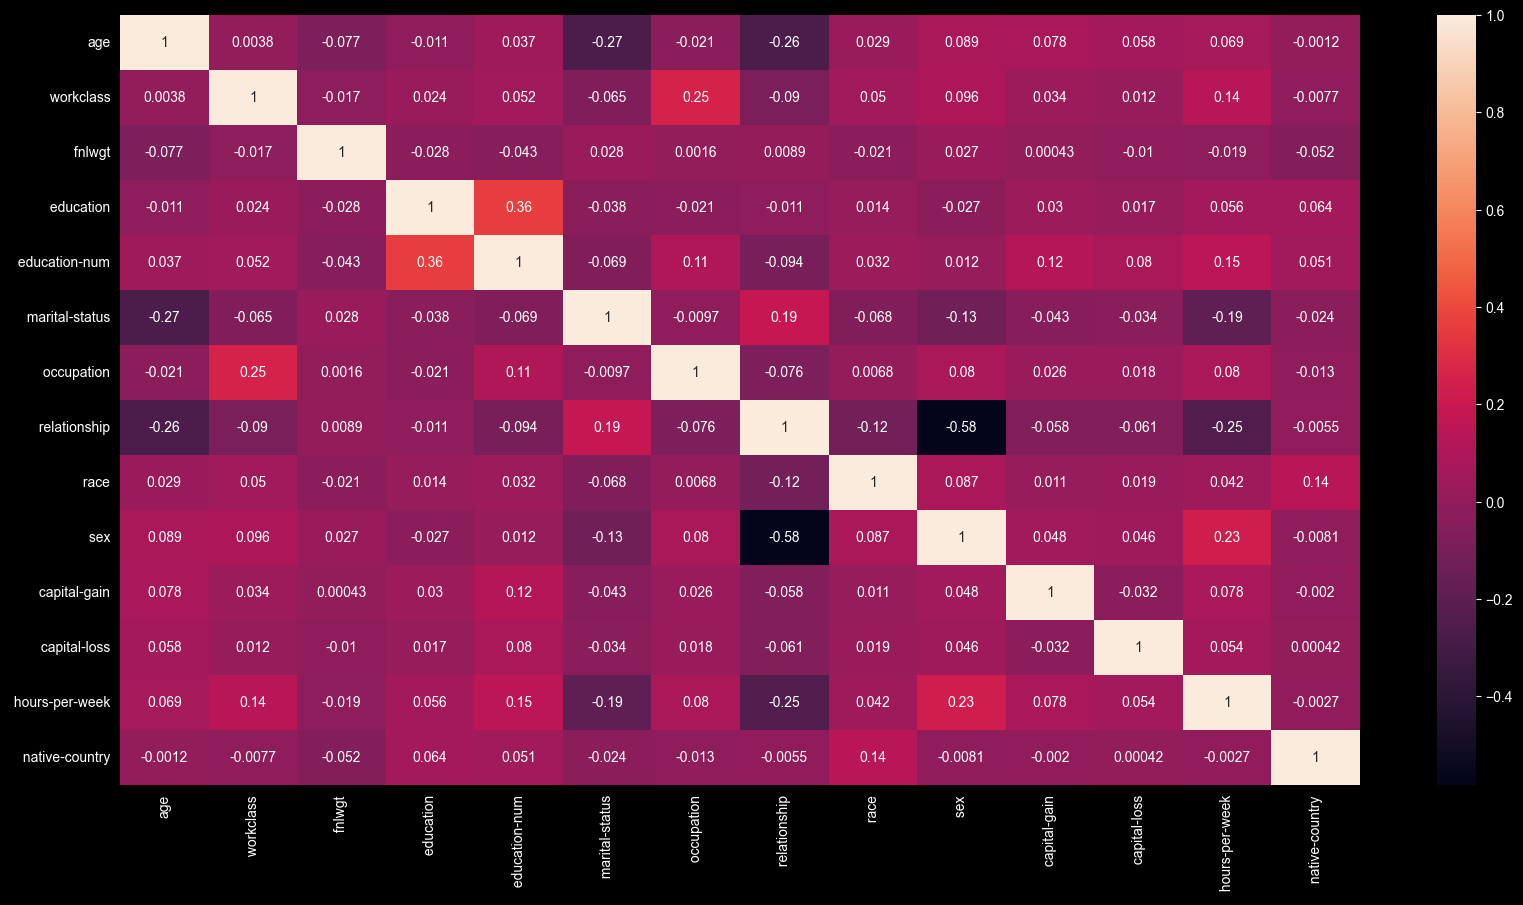

In [20]:
plt.figure(figsize = (20, 10))
sns.heatmap(x.corr(), annot=True, cmap="rocket")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier(max_depth=7)
rfecv3 = RFECV(dt)
rfecv3.fit(x_train, y_train)

print(rfecv3.support_)
print(rfecv3.ranking_)

[False False False False  True False False  True False False  True False
 False False]
[ 3  7  2 12  1 10  6  1  9 11  1  4  5  8]


In [33]:
dt = DecisionTreeClassifier(max_depth=7)
rfecv2 = RFECV(dt)
rfecv2.fit(x_train, y_train)

print(rfecv2.support_)
print(rfecv2.ranking_)

[ True False False False  True False False  True False False  True  True
  True False]
[1 2 6 9 1 4 3 1 7 8 1 1 1 5]


In [42]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [43]:
y_pred_rf = rf.predict(x_test)
y_pred_rf

array([' <=50K', ' <=50K', ' >50K', ..., ' >50K', ' <=50K', ' <=50K'],
      shape=(6513,), dtype=object)

In [34]:
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [35]:
y_pred_dt = dt.predict(x_test)
y_pred_dt

array([' <=50K', ' >50K', ' >50K', ..., ' >50K', ' <=50K', ' <=50K'],
      shape=(6513,), dtype=object)

In [36]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4942
        >50K       0.78      0.56      0.66      1571

    accuracy                           0.86      6513
   macro avg       0.83      0.76      0.78      6513
weighted avg       0.85      0.86      0.85      6513



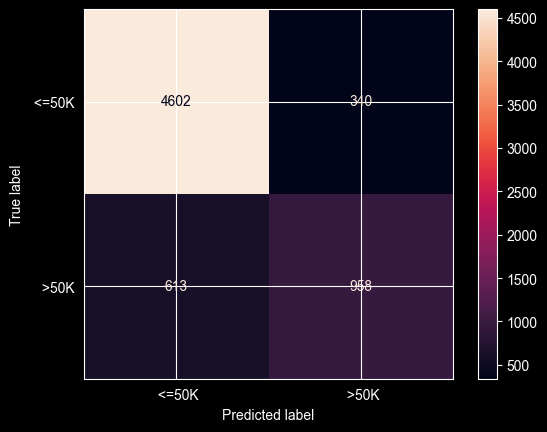

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap='rocket')
plt.show()

In [44]:
from sklearn.metrics import classification_report, accuracy_score
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      4942
        >50K       0.81      0.54      0.64      1571

    accuracy                           0.86      6513
   macro avg       0.84      0.75      0.78      6513
weighted avg       0.85      0.86      0.85      6513



In [48]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
for i in depths:
  rf=RandomForestClassifier(max_depth=i,random_state=42, min_samples_split=2)
  rf.fit(x_train,y_train)
  y_pred_rf =rf.predict(x_test)
  acc=accuracy_score(y_test,y_pred_rf)
  print(f'Max_depth is {i} Accuracy Score is {acc}')

Max_depth is 1 Accuracy Score is 0.7587901120835252
Max_depth is 2 Accuracy Score is 0.8011668969752802
Max_depth is 3 Accuracy Score is 0.8234300629510211
Max_depth is 4 Accuracy Score is 0.8452326116996776
Max_depth is 5 Accuracy Score is 0.8518347919545525
Max_depth is 6 Accuracy Score is 0.8538307999385844
Max_depth is 7 Accuracy Score is 0.8562874251497006
Max_depth is 8 Accuracy Score is 0.8567480423767849
Max_depth is 9 Accuracy Score is 0.8585905112851221
Max_depth is 10 Accuracy Score is 0.8593582066635959
Max_depth is 11 Accuracy Score is 0.8622754491017964
Max_depth is 12 Accuracy Score is 0.8635037617073545
Max_depth is 13 Accuracy Score is 0.866421004145555
Max_depth is 14 Accuracy Score is 0.866421004145555
Max_depth is 15 Accuracy Score is 0.865806847842776
Max_depth is 16 Accuracy Score is 0.8676493167511131
Max_depth is 17 Accuracy Score is 0.865806847842776
Max_depth is 18 Accuracy Score is 0.866421004145555
Max_depth is 19 Accuracy Score is 0.868417012129587
Max_dept

In [45]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  dt=DecisionTreeClassifier(max_depth=i,random_state=42)
  dt.fit(x_train,y_train)
  y_pred_dt=dt.predict(x_test)
  acc=accuracy_score(y_test,y_pred_dt)
  print(f'Max_depth is {i} Accuracy Score is {acc}')

Max_depth is 1 Accuracy Score is 0.7587901120835252
Max_depth is 2 Accuracy Score is 0.826040227237832
Max_depth is 3 Accuracy Score is 0.8415476738830032
Max_depth is 4 Accuracy Score is 0.8487640104406572
Max_depth is 5 Accuracy Score is 0.8550591125441425
Max_depth is 6 Accuracy Score is 0.8549055734684478
Max_depth is 7 Accuracy Score is 0.8572086596038692
Max_depth is 8 Accuracy Score is 0.8570551205281745
Max_depth is 9 Accuracy Score is 0.8561338860740059
Max_depth is 10 Accuracy Score is 0.8572086596038692
Max_depth is 11 Accuracy Score is 0.8539843390142792
Max_depth is 12 Accuracy Score is 0.8527560264087211
Max_depth is 13 Accuracy Score is 0.8536772608628896
